In [2]:
import pandas as pd
import numpy as np

In [6]:
from pathlib import Path

relative_path = Path("data/processed/explore_amazon_cellphones.pkl")
project_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / relative_path).is_file()),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        f"Could not find {relative_path} from {Path.cwd()}. "
        "Check that the file exists and that the data preprocessing step has run."
    )

df = pd.read_pickle(project_root / relative_path)

In [7]:
# 1. Lọc review 1-2 sao
complaints = df[df["overall"].isin([1.0, 2.0])].copy()

print("Complaint reviews:", len(complaints))
print(
    "Percentage:",
    round(len(complaints) / len(df) * 100, 2),
    "%"
)

print("\nRating distribution:")
display(complaints["overall"].value_counts().sort_index())

print("\nYear distribution:")
display(complaints["year"].value_counts().sort_index())

print("\nSample complaints:")
display(
    complaints[
        ["asin", "reviewText", "summary", "overall", "review_date", "year"]
    ].head(10)
)

Complaint reviews: 138671
Percentage: 12.3 %

Rating distribution:


overall
1.0    81505
2.0    57166
Name: count, dtype: int64


Year distribution:


year
2003        3
2004        8
2005       34
2006       85
2007      124
2008      327
2009      457
2010      669
2011     1522
2012     4087
2013    11476
2014    22274
2015    37415
2016    37703
2017    17045
2018     5442
Name: count, dtype: int64


Sample complaints:


,asin,reviewText,summary,overall,review_date,year
3,7508492919,DON'T CARE FOR IT. GAVE IT AS A GIFT AND THEY...,CASE,2.0,2014-02-04,2014
5,7508492919,The product looked exactly like the picture an...,Not so happy,2.0,2014-01-27,2014
8,7508492919,DO NOT BUY! this item is seriously cheap as he...,WORST ITEM!,1.0,2013-12-27,2013
12,7508492919,Very cheap broke the first time we put it on :...,cheap plastic,1.0,2013-10-08,2013
17,7508492919,I used this case for not even a week and the b...,....,2.0,2013-06-27,2013
20,7508492919,The bow fell off multiple times I had to keep ...,Don't waste your money or invest in glue,1.0,2013-05-20,2013
72,7532385086,I was very excited when I first got this case....,A waste of money!,1.0,2011-02-16,2011
75,7887421268,Sent case that didn't fit,One Star,1.0,2014-07-24,2014
76,7887421268,The picture looks waaayyy better than the actu...,"Not so great advertisement, but ok, i guess.",2.0,2014-02-03,2014
83,7887421268,I loved the case when I first received it but ...,Loved it at first,2.0,2012-08-06,2012


In [8]:

# Save checkpoint
output_path = project_root / "data" / "processed" / "complaints_1_2star.pkl"
output_path.parent.mkdir(parents=True, exist_ok=True)

complaints.to_pickle(output_path)
print(f"Saved checkpoint to: {output_path}")

Saved checkpoint to: d:\data mining\e_waste_topic_modeling\data\processed\complaints_1_2star.pkl


In [9]:
print("=== RATING DISTRIBUTION ===")
display(
    complaints["overall"]
    .value_counts()
    .sort_index()
)

=== RATING DISTRIBUTION ===


overall
1.0    81505
2.0    57166
Name: count, dtype: int64

In [11]:
year_counts = (
    complaints["year"]
    .value_counts()
    .sort_index()
)

print("=== COMPLAINTS BY YEAR ===")
display(year_counts)

=== COMPLAINTS BY YEAR ===


year
2003        3
2004        8
2005       34
2006       85
2007      124
2008      327
2009      457
2010      669
2011     1522
2012     4087
2013    11476
2014    22274
2015    37415
2016    37703
2017    17045
2018     5442
Name: count, dtype: int64

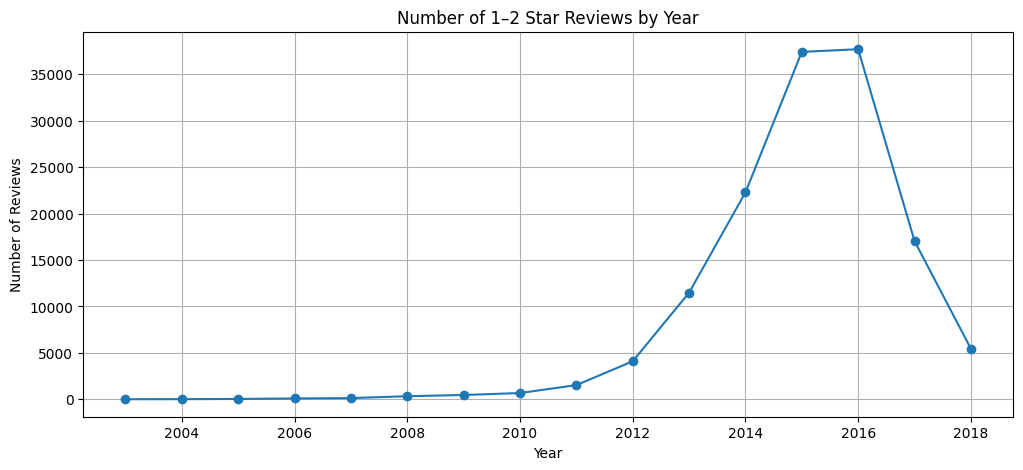

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

year_counts.plot(kind="line", marker="o")

plt.title("Number of 1–2 Star Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

In [13]:
complaints["text_length"] = (
    complaints["reviewText"]
    .fillna("")
    .str.split()
    .str.len()
)

display(
    complaints["text_length"].describe()
)

count    138671.000000
mean         53.723295
std          82.254254
min           0.000000
25%          13.000000
50%          29.000000
75%          63.000000
max        3412.000000
Name: text_length, dtype: float64

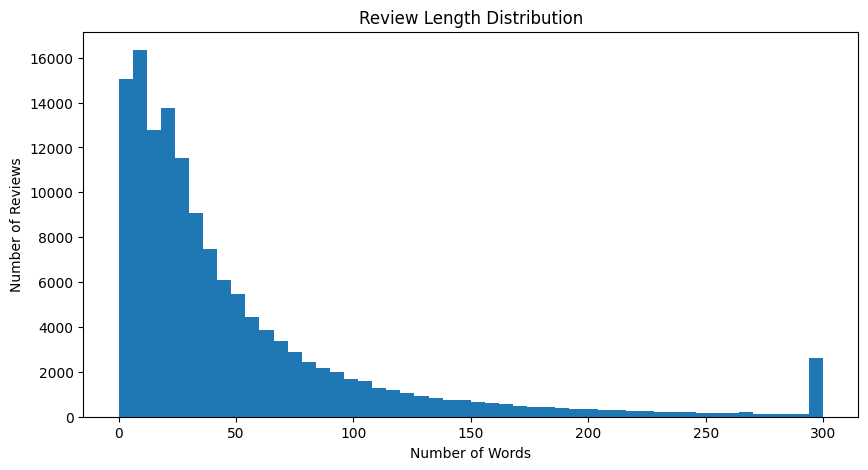

In [14]:
plt.figure(figsize=(10, 5))

complaints["text_length"].clip(upper=300).plot(
    kind="hist",
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

In [15]:
print(
    "Empty reviewText:",
    complaints["reviewText"].isna().sum()
)

print(
    "Empty summary:",
    complaints["summary"].isna().sum()
)

Empty reviewText: 1
Empty summary: 50


In [16]:
display(
    complaints[
        ["reviewText", "summary", "overall"]
    ].sample(20, random_state=42)
)

,reviewText,summary,overall
863519,This failed to protect my brother's phone's di...,Useless,1.0
246567,Its bigb and ugly. I did not like it.,I did not like it.,1.0
783639,Definitely strong enough to protect the screen...,Not exactly a satisfied customer,2.0
689788,"Update, with the rubber popping over the edge ...",Fantastic case in a budget,1.0
696410,ugly as heck,Two Stars,2.0
88012,"bad produce, just for one month and not working.",One Star,1.0
970369,The band is to small to fit around my arm. I ...,The band is to small to fit around my arm ...,2.0
51722,"At first the case was a dream, kick stand, nic...","Could have been great, but is not",2.0
638899,"It's not an OtterBox. I'm sorry, but you can't...",It's not an OtterBox,2.0
494096,Only one chord worked.,Two Stars,2.0


In [17]:
# Complaint rate by year

total_by_year = (
    df.groupby("year")
    .size()
    .rename("total_reviews")
)

complaints_by_year = (
    complaints.groupby("year")
    .size()
    .rename("complaint_reviews")
)

year_analysis = pd.concat(
    [total_by_year, complaints_by_year],
    axis=1
).fillna(0)

year_analysis["complaint_rate"] = (
    year_analysis["complaint_reviews"]
    / year_analysis["total_reviews"]
    * 100
)

display(year_analysis)

,total_reviews,complaint_reviews,complaint_rate
year,,,
2002,2,0.0,0.000000
2003,16,3.0,18.750000
2004,41,8.0,19.512195
2005,132,34.0,25.757576
2006,318,85.0,26.729560
2007,679,124.0,18.262150
2008,1691,327.0,19.337670
2009,2405,457.0,19.002079
2010,3459,669.0,19.340850


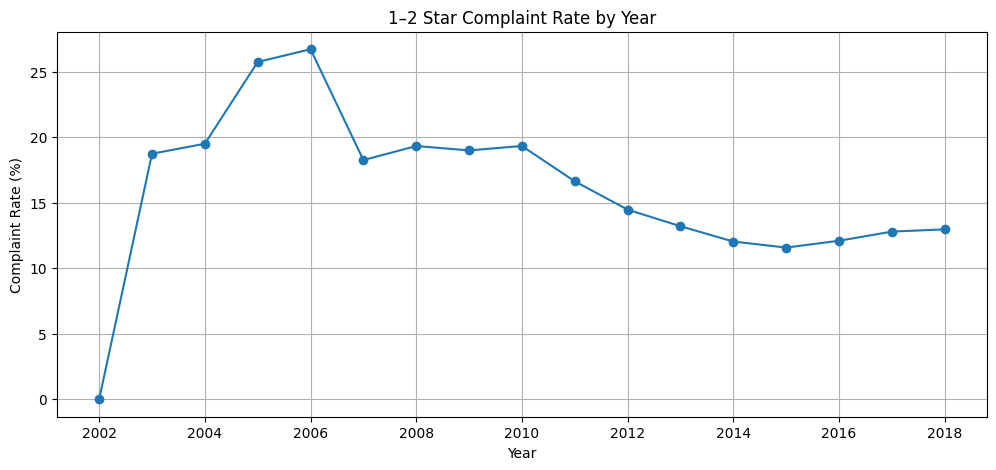

In [18]:
plt.figure(figsize=(12, 5))

year_analysis["complaint_rate"].plot(
    kind="line",
    marker="o"
)

plt.title("1–2 Star Complaint Rate by Year")
plt.xlabel("Year")
plt.ylabel("Complaint Rate (%)")
plt.grid(True)
plt.show()

In [19]:
# Data quality check

print("=== MISSING VALUES ===")
display(complaints.isna().sum())

print("\n=== DUPLICATE REVIEW TEXT ===")
duplicate_count = complaints["reviewText"].duplicated().sum()
print("Duplicate reviewText:", duplicate_count)

print("\n=== REVIEW LENGTH ===")
print(complaints["text_length"].describe())

=== MISSING VALUES ===


asin                   0
reviewText             1
summary               50
overall                0
reviewTime             0
unixReviewTime         0
verified               0
vote              120987
review_date            0
year                   0
text_length            0
dtype: int64


=== DUPLICATE REVIEW TEXT ===
Duplicate reviewText: 7901

=== REVIEW LENGTH ===
count    138671.000000
mean         53.723295
std          82.254254
min           0.000000
25%          13.000000
50%          29.000000
75%          63.000000
max        3412.000000
Name: text_length, dtype: float64


In [20]:
short_review_counts = pd.DataFrame({
    "threshold": ["0 words", "< 3 words", "< 5 words", "< 10 words"],
    "count": [
        (complaints["text_length"] == 0).sum(),
        (complaints["text_length"] < 3).sum(),
        (complaints["text_length"] < 5).sum(),
        (complaints["text_length"] < 10).sum()
    ]
})

short_review_counts["percentage"] = (
    short_review_counts["count"]
    / len(complaints)
    * 100
)

display(short_review_counts)

,threshold,count,percentage
0,0 words,1,0.000721
1,< 3 words,5881,4.240973
2,< 5 words,11871,8.560550
3,< 10 words,26383,19.025607


In [21]:
display(
    complaints.loc[
        complaints["text_length"] < 5,
        ["reviewText", "summary", "overall"]
    ].sample(
        min(30, (complaints["text_length"] < 5).sum()),
        random_state=42
    )
)

,reviewText,summary,overall
153738,horrible case.,One Star,1.0
202988,She love it,Two Stars,2.0
374751,Knockoff,Two Stars,2.0
691147,Malo...,even though the place of the best way possible...,1.0
946047,Arrived not working.,One Star,1.0
559561,Broke to fast,Two Stars,2.0
901384,Crappy,One Star,1.0
714132,Dont buy badly made,Two Stars,2.0
1029486,wasnt for my phone,One Star,1.0
460421,Good,One Star,1.0


In [22]:
complaints_clean = complaints.copy()

# Remove rows with missing review text
complaints_clean = complaints_clean.dropna(
    subset=["reviewText"]
)

# Remove exact duplicate review texts
complaints_clean = complaints_clean.drop_duplicates(
    subset=["reviewText"]
)

print("Original complaints:", len(complaints))
print("After cleaning:", len(complaints_clean))
print(
    "Removed:",
    len(complaints) - len(complaints_clean)
)

Original complaints: 138671
After cleaning: 130769
Removed: 7902


In [23]:
print("Remaining missing reviewText:",
      complaints_clean["reviewText"].isna().sum())

print("Remaining duplicate reviewText:",
      complaints_clean["reviewText"].duplicated().sum())

Remaining missing reviewText: 0
Remaining duplicate reviewText: 0


In [24]:
complaints_clean["summary"] = (
    complaints_clean["summary"]
    .fillna("")
    .astype(str)
)

complaints_clean["text_for_nlp"] = (
    complaints_clean["reviewText"].astype(str)
    + " "
    + complaints_clean["summary"]
)

In [25]:
display(
    complaints_clean[
        ["reviewText", "summary", "text_for_nlp"]
    ].sample(10, random_state=42)
)

,reviewText,summary,text_for_nlp
244578,slow,One Star,slow One Star
25824,While these stay together they work good. Pro...,Sometimes you get what you pay for.,While these stay together they work good. Pro...
371257,Did not work in my car.,Two Stars,Did not work in my car. Two Stars
963057,This product did not adhere correctly to the G...,It felt like a really good piece of tempered g...,This product did not adhere correctly to the G...
372410,The adhesive on the back that is supposed to s...,Not sticky,The adhesive on the back that is supposed to s...
691305,won't stay plugged into the phone. A bit too ...,Two Stars,won't stay plugged into the phone. A bit too ...
281073,It's simply too thick and high around the edge...,There are better brands,It's simply too thick and high around the edge...
1072082,couldn't put on the cover,One Star,couldn't put on the cover One Star
160499,My phone did not even fit in it. It was cute t...,Doesn't fit on my phone.,My phone did not even fit in it. It was cute t...
735434,Got it 28 November and on 7 January the belt c...,I like the case,Got it 28 November and on 7 January the belt c...


In [26]:
rating_summaries = [
    "one star",
    "two stars",
    "one-star",
    "two-star",
    "one stars",
    "two star"
]

complaints_clean["summary_for_nlp"] = (
    complaints_clean["summary"]
    .str.lower()
    .str.strip()
)

complaints_clean.loc[
    complaints_clean["summary_for_nlp"].isin(rating_summaries),
    "summary_for_nlp"
] = ""

In [27]:
complaints_clean["text_for_nlp"] = (
    complaints_clean["reviewText"].astype(str)
    + " "
    + complaints_clean["summary_for_nlp"].astype(str)
).str.strip()

In [28]:
display(
    complaints_clean[
        ["reviewText", "summary", "summary_for_nlp", "text_for_nlp"]
    ].sample(10, random_state=42)
)

,reviewText,summary,summary_for_nlp,text_for_nlp
244578,slow,One Star,,slow
25824,While these stay together they work good. Pro...,Sometimes you get what you pay for.,sometimes you get what you pay for.,While these stay together they work good. Pro...
371257,Did not work in my car.,Two Stars,,Did not work in my car.
963057,This product did not adhere correctly to the G...,It felt like a really good piece of tempered g...,it felt like a really good piece of tempered g...,This product did not adhere correctly to the G...
372410,The adhesive on the back that is supposed to s...,Not sticky,not sticky,The adhesive on the back that is supposed to s...
691305,won't stay plugged into the phone. A bit too ...,Two Stars,,won't stay plugged into the phone. A bit too ...
281073,It's simply too thick and high around the edge...,There are better brands,there are better brands,It's simply too thick and high around the edge...
1072082,couldn't put on the cover,One Star,,couldn't put on the cover
160499,My phone did not even fit in it. It was cute t...,Doesn't fit on my phone.,doesn't fit on my phone.,My phone did not even fit in it. It was cute t...
735434,Got it 28 November and on 7 January the belt c...,I like the case,i like the case,Got it 28 November and on 7 January the belt c...


In [29]:
display(
    complaints_clean[
        ["reviewText", "summary", "overall"]
    ].sample(20, random_state=42)
)

,reviewText,summary,overall
244578,slow,One Star,1.0
25824,While these stay together they work good. Pro...,Sometimes you get what you pay for.,2.0
371257,Did not work in my car.,Two Stars,2.0
963057,This product did not adhere correctly to the G...,It felt like a really good piece of tempered g...,2.0
372410,The adhesive on the back that is supposed to s...,Not sticky,1.0
691305,won't stay plugged into the phone. A bit too ...,Two Stars,2.0
281073,It's simply too thick and high around the edge...,There are better brands,2.0
1072082,couldn't put on the cover,One Star,1.0
160499,My phone did not even fit in it. It was cute t...,Doesn't fit on my phone.,1.0
735434,Got it 28 November and on 7 January the belt c...,I like the case,1.0


In [30]:
# Kiểm tra reviewText trước khi NLP preprocessing

print("Missing reviewText:", complaints["reviewText"].isna().sum())
print("Duplicate reviewText:", complaints["reviewText"].duplicated().sum())
print()

print("Một số review ngắn:")
display(
    complaints[
        ["overall", "reviewText", "summary"]
    ]
    .sort_values("reviewText", key=lambda x: x.astype(str).str.len())
    .head(20)
)

print()
print("Thống kê độ dài review (số ký tự):")
print(
    complaints["reviewText"]
    .astype(str)
    .str.len()
    .describe()
)

Missing reviewText: 1
Duplicate reviewText: 7901

Một số review ngắn:


,overall,reviewText,summary
273198,1.0,b,One Star
229685,1.0,a,a
63280,2.0,1,Two Stars
1069506,1.0,e,One Star
288033,2.0,k,Two Stars
62041,1.0,E,One Star
776295,2.0,a,Two Stars
436324,1.0,c,One Star
258109,2.0,A,Two Stars
73433,1.0,1,One Star



Thống kê độ dài review (số ký tự):
count    138670.000000
mean        285.584726
std         449.217429
min           1.000000
25%          68.000000
50%         153.000000
75%         328.000000
max       19860.000000
Name: reviewText, dtype: float64


In [31]:
# Remove reviews that contain only 1 character
complaints_clean = complaints_clean[
    complaints_clean["reviewText"].str.strip().str.len() > 1
].copy()

print("After removing 1-character reviews:", len(complaints_clean))

After removing 1-character reviews: 130757


In [32]:
display(
    complaints_clean[
        ["overall", "reviewText", "summary"]
    ]
    .assign(
        text_length=lambda x: x["reviewText"].str.len()
    )
    .sort_values("text_length")
    .head(30)
)

,overall,reviewText,summary,text_length
15081,2.0,Ok,Two Stars,2
240971,2.0,ty,Two Stars,2
151399,1.0,Eh,One Star,2
1041665,2.0,:(,Two Stars,2
263196,1.0,no,One Star,2
30802,2.0,No,Two Stars,2
15506,1.0,OK,One Star,2
523757,2.0,7t,Two Stars,2
1082826,2.0,;(,Two Stars,2
983449,1.0,My,Ph,2


In [33]:
print("Final complaints_clean:", len(complaints_clean))

Final complaints_clean: 130757


In [34]:
output_path = (
    project_root
    / "data"
    / "processed"
    / "complaints_clean.pkl"
)

complaints_clean.to_pickle(output_path)

print("Saved:", output_path)
print("Shape:", complaints_clean.shape)

Saved: d:\data mining\e_waste_topic_modeling\data\processed\complaints_clean.pkl
Shape: (130757, 13)
